<a href="https://colab.research.google.com/github/yuri-spizhovyi-mit/ET6-ML/blob/main/module_2/market_segmentation_for_airlines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ✈️ Market Segmentation for Airlines – MIT UAI Course

**Author:** Yuri Spizhovyi  
**Source:** [Machine Learning for the MIT UAI Program](https://courses.mitxonline.mit.edu/)  
**Dataset:** `AirlinesCluster.csv` (Frequent flyer program data – 3,999 customers)  
**Repo:** [My Repo](https://github.com/yuri-spizhovyi-mit/ET6-ML)



---

This notebook presents a step-by-step solution to the **Market Segmentation for Airlines** assignment from the MIT UAI Course.  
It applies unsupervised learning techniques, primarily **k-means clustering**, to segment airline customers based on their mileage and transaction patterns.

> 📌 **Goal**: Identify similar groups of customers in an airline’s frequent flyer program to enable more effective targeting of mileage offers and promotions.


In [96]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

!git clone https://github.com/yuri-spizhovyi-mit/ET6-ML.git
%cd ET6-ML/module_2

Cloning into 'ET6-ML'...
remote: Enumerating objects: 311, done.
remote: Counting objects: 100% (59/59), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 311 (delta 36), reused 28 (delta 24), pack-reused 252 (from 1)
Receiving objects: 100% (311/311), 14.77 MiB | 6.92 MiB/s, done.
Resolving deltas: 100% (159/159), done.
/content/ET6-ML/module_2/ET6-ML/module_2/ET6-ML/module_2/ET6-ML/module_2/ET6-ML/module_2/ET6-ML/module_2


In [97]:
df_airlines = pd.read_csv('AirlinesCluster.csv')
df_airlines.head()

,Balance,QualMiles,BonusMiles,BonusTrans,FlightMiles,FlightTrans,DaysSinceEnroll
0,28143,0,174,1,0,0,7000
1,19244,0,215,2,0,0,6968
2,41354,0,4123,4,0,0,7034
3,14776,0,500,1,0,0,6952
4,97752,0,43300,26,2077,4,6935


In [98]:
df_airlines.describe()

,Balance,QualMiles,BonusMiles,BonusTrans,FlightMiles,FlightTrans,DaysSinceEnroll
count,3.999000e+03,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000
mean,7.360133e+04,144.114529,17144.846212,11.60190,460.055764,1.373593,4118.55939
std,1.007757e+05,773.663804,24150.967826,9.60381,1400.209171,3.793172,2065.13454
min,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,2.00000
25%,1.852750e+04,0.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000
50%,4.309700e+04,0.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000
75%,9.240400e+04,0.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000
max,1.704838e+06,11148.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000


In [99]:
std_of_colums = []
for col in df_airlines.columns:
  std_of_colums.append((df_airlines[col].mean(), col))
  #print(df_airlines[col].mean())
sorted_airlines = sorted(std_of_colums)
print(sorted_airlines[:2])
print(sorted_airlines[-2:])

[(np.float64(1.3735933983495874), 'FlightTrans'), (np.float64(11.60190047511878), 'BonusTrans')]
[(np.float64(17144.84621155289), 'BonusMiles'), (np.float64(73601.32758189547), 'Balance')]


In [100]:
mean_list = [(df_airlines[col].mean(), col) for col in df_airlines.columns]
mean_sorted = sorted(mean_list)

print("Smallest average values:", mean_sorted[:2])
print("Largest average values:", mean_sorted[-2:])


Smallest average values: [(np.float64(1.3735933983495874), 'FlightTrans'), (np.float64(11.60190047511878), 'BonusTrans')]
Largest average values: [(np.float64(17144.84621155289), 'BonusMiles'), (np.float64(73601.32758189547), 'Balance')]


## Normalization of data

In [101]:
df_airlines_normalized = df_airlines.copy()
for col in df_airlines.columns:
    df_airlines_normalized[col] = (df_airlines[col] - df_airlines[col].mean()) / df_airlines[col].std()
max_value = df_airlines_normalized.max()
min_value = df_airlines_normalized.min()
print(f"Max value is {max_value}")
print(f"Min value is {min_value}")

Max value is Balance            16.186811
QualMiles          14.223084
BonusMiles         10.208293
BonusTrans          7.746727
FlightMiles        21.680292
FlightTrans        13.610351
DaysSinceEnroll     2.022842
dtype: float64
Min value is Balance           -0.730348
QualMiles         -0.186275
BonusMiles        -0.709903
BonusTrans        -1.208052
FlightMiles       -0.328562
FlightTrans       -0.362123
DaysSinceEnroll   -1.993361
dtype: float64


In [102]:
max_col = df_airlines_normalized.max().idxmax()
max_val = df_airlines_normalized[max_col].max()
print(f"Largest maximum value is in '{max_col}': {max_val}")


Largest maximum value is in 'FlightMiles': 21.680292385902458


In [103]:
min_col = df_airlines_normalized.min().idxmin()
min_val = df_airlines_normalized[min_col].min()
print(f"Smallest minimum value is in '{min_col}': {min_val}")
print(min_col)

Smallest minimum value is in 'DaysSinceEnroll': -1.9933613571692343
DaysSinceEnroll


## Hierarchical distance calculating based on distance matrix

In [104]:
from sklearn.metrics import pairwise_distances, accuracy_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
df_airlines_distance = pairwise_distances(df_airlines_normalized, metric='euclidean')

# Perform hierarchical clustering
df_hier_clustering = linkage(df_airlines_normalized, method='ward')

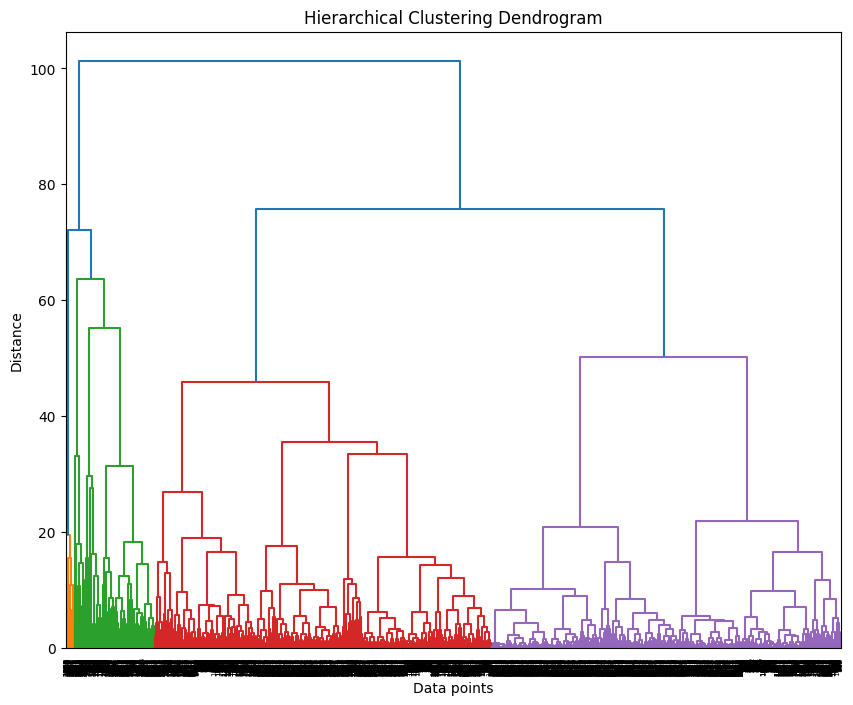

In [105]:
# Plot dendrogram
plt.figure(figsize=(10, 8))
dendrogram(df_hier_clustering)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data points")
plt.ylabel("Distance")
plt.show()

In [106]:
# Cut the dendrogram into 5 clusters
hier_groups = fcluster(df_hier_clustering, t=5, criterion='maxclust')
print(hier_groups)

[5 5 5 ... 5 5 5]


In [107]:
# Number of points in each group
print(pd.Series(hier_groups).value_counts())

5    1801
4    1737
3     360
2      53
1      48
Name: count, dtype: int64


In [124]:
# Individual variable averages.
for col in df_airlines.columns:
  print(df_airlines.groupby(hier_groups)[col].mean())

1    135318.020833
2    154830.603774
3    204316.227778
4     79910.013241
5     37353.074403
Name: Balance, dtype: float64
1    5870.062500
2     490.716981
3     144.711111
4     123.694876
5       0.882288
Name: QualMiles, dtype: float64
1    16406.000000
2    32137.018868
3    36265.022222
4    26735.156592
5     3651.923931
Name: BonusMiles, dtype: float64
1    12.645833
2    33.471698
3    19.802778
4    16.832470
5     4.246530
Name: BonusTrans, dtype: float64
1     974.770833
2    8752.622642
3    2286.719444
4     148.672424
5     137.491394
Name: FlightMiles, dtype: float64
1     3.270833
2    23.679245
3     6.744444
4     0.483592
5     0.451416
Name: FlightTrans, dtype: float64
1    4320.375000
2    4046.830189
3    4744.158333
4    4727.468048
5    3402.970572
Name: DaysSinceEnroll, dtype: float64


In [125]:
# Max average value for each variable across clusters
for col in df_airlines.columns:
    group_means = df_airlines.groupby(hier_groups)[col].mean()
    max_cluster = group_means.idxmax()
    max_value = group_means.max()
    print(f"{col}: Cluster {max_cluster} has the highest average = {max_value:.2f}")


Balance: Cluster 3 has the highest average = 204316.23
QualMiles: Cluster 1 has the highest average = 5870.06
BonusMiles: Cluster 3 has the highest average = 36265.02
BonusTrans: Cluster 2 has the highest average = 33.47
FlightMiles: Cluster 2 has the highest average = 8752.62
FlightTrans: Cluster 2 has the highest average = 23.68
DaysSinceEnroll: Cluster 3 has the highest average = 4744.16


In [128]:
# Min average value for each variable across clusters
for col in df_airlines.columns:
    group_means = df_airlines.groupby(hier_groups)[col].mean()
    min_cluster = group_means.idxmin() # cluster number with lowest average
    min_value = group_means.min() # the actual lowest average value
    print(f"{col}: Cluster {min_cluster} has the lowest average = {min_value:.2f}")


Balance: Cluster 5 has the lowest average = 37353.07
QualMiles: Cluster 5 has the lowest average = 0.88
BonusMiles: Cluster 5 has the lowest average = 3651.92
BonusTrans: Cluster 5 has the lowest average = 4.25
FlightMiles: Cluster 5 has the lowest average = 137.49
FlightTrans: Cluster 5 has the lowest average = 0.45
DaysSinceEnroll: Cluster 5 has the lowest average = 3402.97
